# Resnet-18 Model Baseline Training

In [1]:
# imports
import torch
import numpy as np
import torchvision
from torchvision.datasets import CIFAR10
from torchvision.transforms import ToTensor
from torch.utils.data.sampler import SubsetRandomSampler
from torch.utils.data.dataloader import DataLoader
import matplotlib.pyplot as plt
%matplotlib inline

## Initializing Datasets & DataLoaders

In [2]:
from torchvision import datasets, transforms

# statistics for CIFAR10 for the ResNet model preprocessing
mean = (0.4914, 0.4822, 0.4465)
std = (0.2023, 0.1994, 0.2010)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# get cifar10 datatset, both train and test
train_dataset = CIFAR10(root='/data', download=True, train=True,transform=train_transform)
test_dataset = CIFAR10(root='/data', download=True, train=False,transform=test_transform)
len(train_dataset), len(test_dataset)

C:\Users\shehe\projects\ai-paper-reproductions\resnet\venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


(50000, 10000)

In [3]:
# global random seed for all experiments to ensure reproducibility
seed = 42
torch.manual_seed(seed)
g = torch.Generator()
g.manual_seed(seed)

In [4]:
from torch.utils.data import random_split

val_size = 10000
train_size = len(train_dataset) - val_size

train_ds, val_ds = random_split(train_dataset, [train_size, val_size], generator=g)

In [5]:
# DataLoaders
from torch.utils.data import DataLoader

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=0, generator=g)
val_loader = DataLoader(val_ds, batch_size=128, shuffle=True, num_workers=0, generator=g)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=0)

# check
images, labels = next(iter(train_loader))
print(images.shape, labels.shape)

images, labels = next(iter(test_loader))
print(images.shape, labels.shape)

torch.Size([128, 3, 32, 32]) torch.Size([128])
torch.Size([128, 3, 32, 32]) torch.Size([128])


## Model Setup

In [6]:
# get the model
import sys
import os

# Adds the parent directory to the python path
sys.path.append(os.path.abspath('..'))
from models.resnet import resnet18
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = resnet18(num_classes=10)
model = model.to(device)

### Training Components

In [7]:
from torch import nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR

# loss function
criterion = nn.CrossEntropyLoss()

# optimizer
optimizer = optim.SGD(
    model.parameters(),
    lr=0.1,
    momentum=0.9,
    weight_decay=1e-4
)

# scheduler
num_epochs = 15
scheduler = StepLR(optimizer, step_size=5, gamma=0.1)

In [8]:
def recorded_time(elapsed_time):
    minutes = int(elapsed_time // 60)
    seconds = round((elapsed_time / 60 - minutes) * 60)
    print(f"time: {minutes}m {seconds}s")

## Training and Validating the Baseline Model

In [9]:
from models.resnet import fit
from time import time

# training
start_time = time() # start the timer
history = fit(
    model,
    num_epochs,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    device
)
elapsed = time() - start_time    
recorded_time(elapsed)

Epoch 1/15:
	Train   Loss: 2.2684 | Train   Acc: 0.2668
	Val     Loss: 1.7031   | Val     Acc: 0.3671
Epoch 2/15:
	Train   Loss: 1.6219 | Train   Acc: 0.4023
	Val     Loss: 1.5163   | Val     Acc: 0.4359
Epoch 3/15:
	Train   Loss: 1.4733 | Train   Acc: 0.4611
	Val     Loss: 1.4368   | Val     Acc: 0.4830
Epoch 4/15:
	Train   Loss: 1.3500 | Train   Acc: 0.5123
	Val     Loss: 1.3505   | Val     Acc: 0.5119
Epoch 5/15:
	Train   Loss: 1.2214 | Train   Acc: 0.5616
	Val     Loss: 1.1659   | Val     Acc: 0.5821
Epoch 6/15:
	Train   Loss: 1.0507 | Train   Acc: 0.6266
	Val     Loss: 1.0233   | Val     Acc: 0.6360
Epoch 7/15:
	Train   Loss: 1.0073 | Train   Acc: 0.6427
	Val     Loss: 1.0187   | Val     Acc: 0.6380
Epoch 8/15:
	Train   Loss: 0.9810 | Train   Acc: 0.6528
	Val     Loss: 0.9906   | Val     Acc: 0.6483
Epoch 9/15:
	Train   Loss: 0.9511 | Train   Acc: 0.6631
	Val     Loss: 0.9694   | Val     Acc: 0.6541
Epoch 10/15:
	Train   Loss: 0.9344 | Train   Acc: 0.6678
	Val     Loss: 0.9656   |

## Test

In [10]:
from models.resnet import evaluate

# test
result = evaluate(model, test_loader, criterion, device)
print(f"Test loss: {result[0]:.4f}, Test acc: {result[1]:.4f}")

Test loss: 0.8954, Test acc: 0.6976


## Results

In [18]:
# make data of training and validtion for loss and accuracy plots

train_metrics = history['training']
val_metrics = history['validation']

train_loss = [ loss for loss,_ in train_metrics]
train_acc = [ acc for _,acc in train_metrics]

val_loss = [ loss for loss,_ in val_metrics]
val_acc = [ acc for _,acc in val_metrics]
    

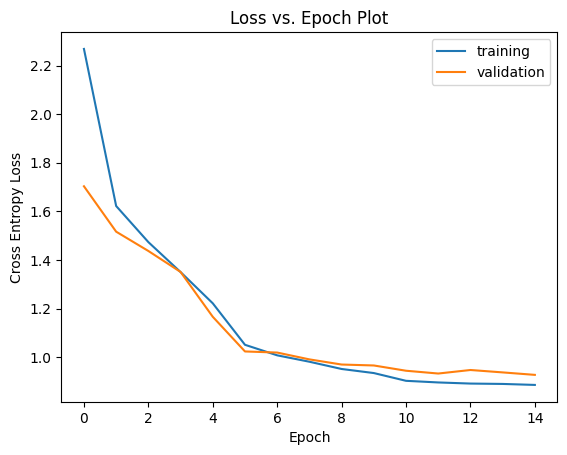

In [22]:
import matplotlib.pyplot as plt
# make plot for loss

plt.plot(train_loss, label="training")
plt.plot(val_loss, label="validation")
plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.title("Loss vs. Epoch Plot")
plt.legend()
plt.savefig('./images/baseline_loss_plot.png')
plt.show()

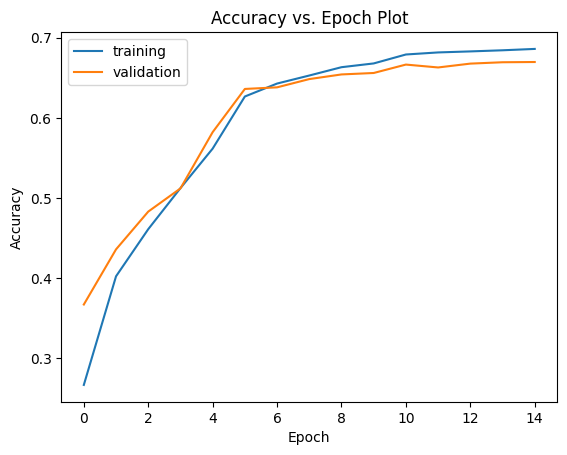

In [23]:
import matplotlib.pyplot as plt
# make plot for accuracy

plt.plot(train_acc, label="training")
plt.plot(val_acc, label="validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs. Epoch Plot")
plt.legend()
plt.savefig('./images/baseline_accuracy_plot.png')
plt.show()

## Discussion/Notes

Baseline ResNet-18 on CIFAR-10
- Stem: 7x7 conv, stride 2 + maxpool
- Epochs: 15
- Optimizer: SGD(lr=0.1, momentum=0.9, weight_decay=1e-4)
- Scheduler: StepLR(gamma=0.1)
- Augmentation: random crop, horizontal flip
- Final train acc: 68.59%
- Final val acc: 66.96%
- Test acc: 0.6976
- Runtime: 53m 12s on CPU

### Interpretation
The baseline confirms the implementation is correct and trainable.
Residual learning worked as expected, with smooth optimization and no major overfitting.
Performance is decent but likely limited by short training and the ImageNet-style stem being suboptimal for CIFAR-10.